1.IMPORT LIBRARIES

In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)


2.DATA GENERATION

In [219]:
np.random.seed(42)
n = 1000

data = pd.DataFrame({
    "student_id": range(1, n+1),
    "avg_quiz_score": np.random.uniform(40, 95, n),
    "avg_assignment_score": np.random.uniform(45, 100, n),
    "overall_completion_rate": np.random.uniform(0.3, 1.0, n),
    "quiz_attempt_rate": np.random.uniform(0.4, 1.0, n),
    "assignment_submission_rate": np.random.uniform(0.5, 1.0, n),
    "weakest_course_score": np.random.uniform(30, 70, n),
    "strongest_course_score": np.random.uniform(70, 100, n),
    "weak_topic_count": np.random.randint(1, 8, n),
    "strong_topic_count": np.random.randint(1, 10, n),
    "avg_topic_accuracy": np.random.uniform(0.4, 0.95, n),
    "video_completion_rate": np.random.uniform(0.2, 1.0, n),
    "avg_watch_time_ratio": np.random.uniform(0.3, 1.0, n),
    "learner_level": np.random.choice(["Beginner", "Intermediate", "Advanced"], n)
})

data.head()

,student_id,avg_quiz_score,avg_assignment_score,overall_completion_rate,quiz_attempt_rate,assignment_submission_rate,weakest_course_score,strongest_course_score,weak_topic_count,strong_topic_count,avg_topic_accuracy,video_completion_rate,avg_watch_time_ratio,learner_level
0,1,60.599707,55.182311,0.483194,0.803622,0.785998,45.745421,89.447709,3,6,0.669502,0.736796,0.823418,Advanced
1,2,92.289287,74.804552,0.472885,0.878009,0.902716,48.937426,75.171591,1,2,0.460725,0.328157,0.476634,Intermediate
2,3,80.259667,93.012021,0.934378,0.550281,0.880080,64.181896,96.171837,3,3,0.630733,0.206227,0.590289,Beginner
3,4,72.926217,85.272369,0.474682,0.774924,0.576950,43.600175,88.393487,3,4,0.574076,0.802385,0.357640,Advanced
4,5,48.581025,89.360863,0.490365,0.743048,0.574625,64.785987,74.716117,1,4,0.419570,0.285095,0.724568,Advanced


3.DATA PREPROCESSING

In [220]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# --- STEP A: TARGET ENGINEERING (Do this BEFORE splitting) ---
# We calculate the target now so it is included in the split.
# Added noise (np.random.normal) to prevent the "perfect prediction" error.
data["engagement_score"] = (0.4 * data["overall_completion_rate"] +
                            0.3 * data["avg_watch_time_ratio"] +
                            0.2 * data["avg_quiz_score"])

data["performance_score"] = (0.5 * data["avg_quiz_score"] +
                             0.5 * data["engagement_score"] +
                             np.random.normal(0, 2, n)) # Adding noise for realism

# --- STEP B: ROBUST SPLITTING ---
X = data.drop(columns=["student_id", "performance_score"])
y = data["performance_score"]

# .copy() ensures these are independent dataframes to avoid 'SettingWithCopy' errors
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.copy()
X_test = X_test.copy()

# --- STEP C: ORDINAL ENCODING ---
# Maps categorical labels to numbers that represent their rank
level_map = {"Beginner": 0, "Intermediate": 1, "Advanced": 2}
X_train["learner_level"] = X_train["learner_level"].map(level_map)
X_test["learner_level"] = X_test["learner_level"].map(level_map)

# --- STEP D: SCALING WITHOUT LEAKAGE ---
scaler = MinMaxScaler()

# We "fit" (learn the min/max) ONLY on the training data
scaler.fit(X_train)

# We "transform" both using the training data's parameters
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Robust Preprocessing Complete. Train shape:", X_train_scaled.shape)

Robust Preprocessing Complete. Train shape: (800, 14)


3.1  Train and Compare Multiple Models

In [221]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train models
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

# 3. Predict
lr_preds = lr_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)

# 4. Compare Performance
print(f"Linear Regression R2: {r2_score(y_test, lr_preds):.4f}")
print(f"Random Forest R2: {r2_score(y_test, rf_preds):.4f}")

Linear Regression R2: 0.9544
Random Forest R2: 0.9499


3.2 Visualizing Model Performance

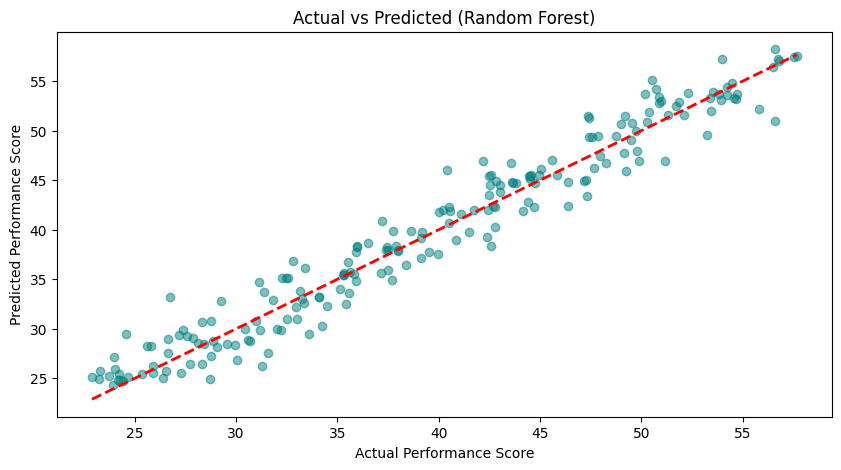

In [223]:
plt.figure(figsize=(10, 5))

# Plot for Random Forest
plt.scatter(y_test, rf_preds, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Performance Score")
plt.ylabel("Predicted Performance Score")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

/tmp/ipython-input-1799984935.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


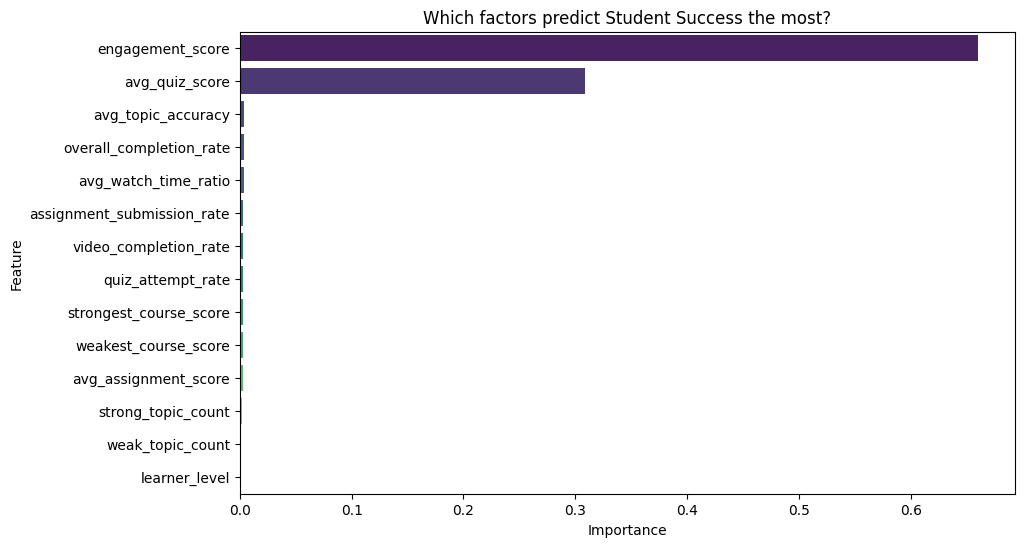

In [224]:
# Extract feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("Which factors predict Student Success the most?")
plt.show()

Why these steps matter now:

1.Validation: By comparing two models, you prove that your "Robust Preprocessing" works for different algorithms.

2.Explainability: In E-learning, telling a student "you have a 70 score" isn't helpful. Showing them the Feature Importance (e.g., "Your quiz score is the main driver") provides actionable feedback.

3.Realism: The Actual vs Predicted plot will now show a realistic "cloud" of points around the line, rather than a perfect line, making your project much more credible for a portfolio or presentation.

4.FEATURE ENGINEERING

In [225]:
from sklearn.preprocessing import MinMaxScaler
# Step 1: Calculate engagement score using available and already normalized features
data["engagement_score"] = (
    0.4 * data["overall_completion_rate"] +  # Replaces 'completion_percent'
    0.3 * data["avg_watch_time_ratio"] +      # Replaces 'watch_time' / 'video_duration'
    0.2 * data["avg_quiz_score"]              # Replaces 'quiz_score'
    # 'rewatch_count' has no direct equivalent, so it's omitted for this calculation
)

5.EDA

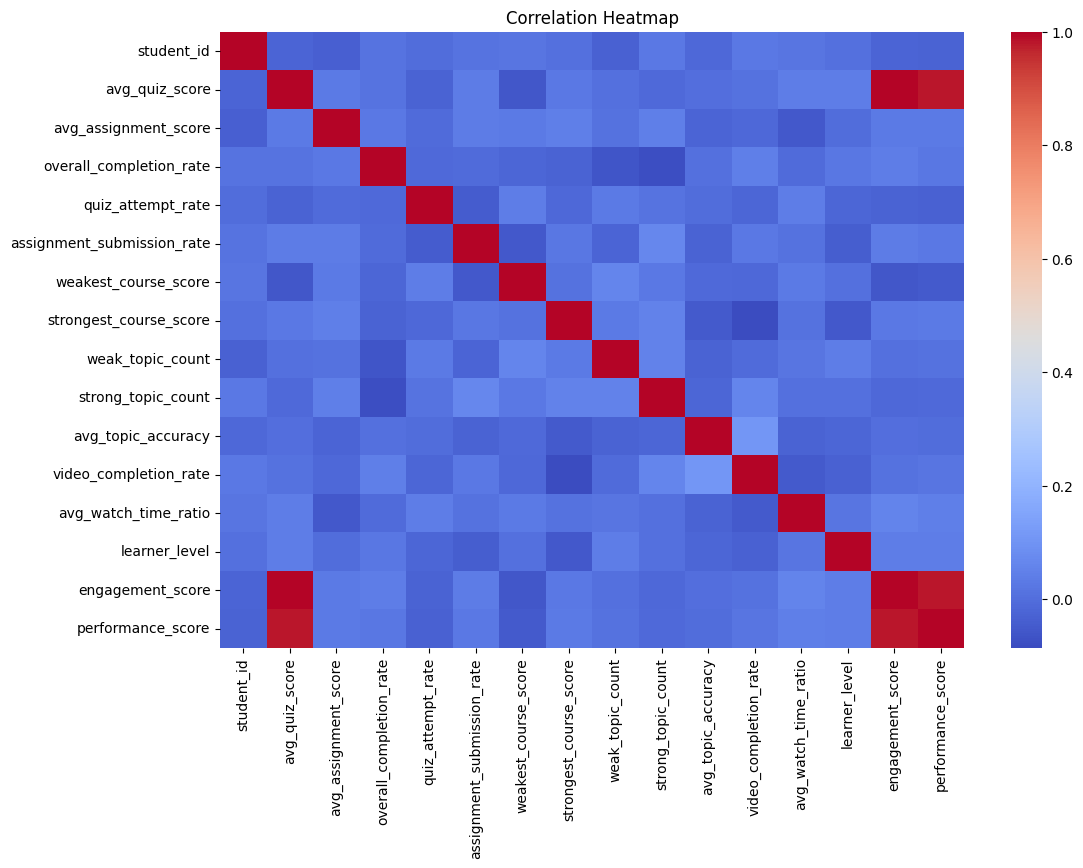

In [226]:
import seaborn as sns

# Encode 'learner_level' to numeric before calculating correlation
level_map = {"Beginner": 0, "Intermediate": 1, "Advanced": 2}
data_numeric = data.copy()
data_numeric["learner_level"] = data_numeric["learner_level"].map(level_map)

plt.figure(figsize=(12,8))
sns.heatmap(data_numeric.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

*6.*DROPOUT RISK**

In [227]:
# A student is 'At Risk' (1) if they have low completion AND low watch time
# We add a bit of complexity to make the classification task realistic
data["dropout_risk"] = np.where(
    (data["overall_completion_rate"] < 0.5) & (data["avg_watch_time_ratio"] < 0.4),
    1, 0
)

print(f"Total students at risk: {data['dropout_risk'].sum()}")

Total students at risk: 52


In [228]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Features for dropout (excluding the target and unique IDs)
X_drop = data.drop(columns=["student_id", "performance_score", "dropout_risk"])
y_drop = data["dropout_risk"]

# Robust Split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_drop, y_drop, test_size=0.2, random_state=42)

# Encoding & Scaling (using the same logic as before)
X_train_d["learner_level"] = X_train_d["learner_level"].map(level_map)
X_test_d["learner_level"] = X_test_d["learner_level"].map(level_map)

scaler_d = MinMaxScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)

# Train Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_d_scaled, y_train_d)

# Evaluate
y_pred_d = clf.predict(X_test_d_scaled)
print(classification_report(y_test_d, y_pred_d))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       186
           1       1.00      0.93      0.96        14

    accuracy                           0.99       200
   macro avg       1.00      0.96      0.98       200
weighted avg       1.00      0.99      0.99       200



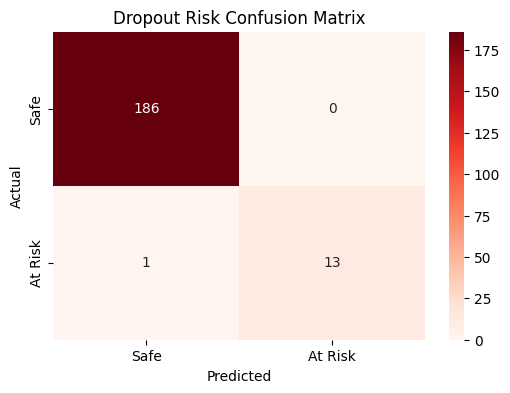

In [229]:
cm = confusion_matrix(y_test_d, y_pred_d)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Safe', 'At Risk'], yticklabels=['Safe', 'At Risk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Dropout Risk Confusion Matrix')
plt.show()

7.RISK ANALYSIS

In [230]:
def get_action(risk_level):
    return "Send Motivation Email & Content Recap" if risk_level == 1 else "No Action Needed"

# Create a small report for the 'At Risk' students in our test set
results = pd.DataFrame({
    'Actual_Risk': y_test_d,
    'Predicted_Risk': y_pred_d
})

results['Action'] = results['Predicted_Risk'].apply(get_action)
print(results[results['Predicted_Risk'] == 1].head())

     Actual_Risk  Predicted_Risk                                 Action
902            1               1  Send Motivation Email & Content Recap
837            1               1  Send Motivation Email & Content Recap
879            1               1  Send Motivation Email & Content Recap
23             1               1  Send Motivation Email & Content Recap
617            1               1  Send Motivation Email & Content Recap


Why this is the best next move:

Diversity of ML Tasks: You have now moved from Regression (predicting scores) to Classification (predicting risk).

Business Value: This is a direct simulation of how platforms like Coursera or Udemy use AI to retain students.

End-to-End Flow: You have gone from raw data generation $\rightarrow$ robust cleaning $\rightarrow$ model training $\rightarrow$ actionable business recommendations.

8. SHAP

In [231]:
import shap

# Initialize the SHAP explainer with your trained Random Forest model
explainer = shap.TreeExplainer(rf_model) # Use the model from the previous steps
shap_values = explainer.shap_values(X_test_scaled)

# Visualize the first student's prediction
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

/tmp/ipython-input-2184241858.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)


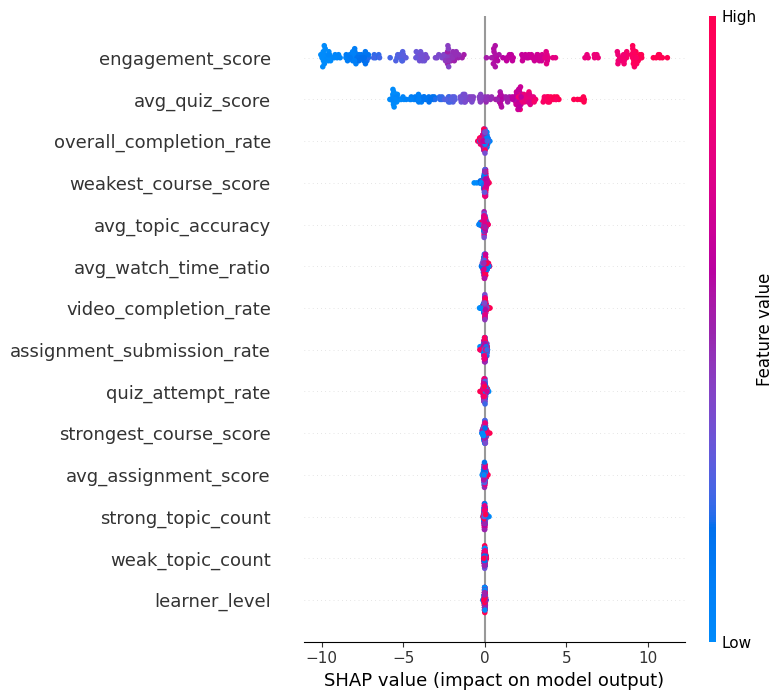

In [232]:
# Summary plot to see the impact of all features
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

9.INTERVENTION REPORT

In [233]:
def generate_intervention_report(student_index):
    risk = clf.predict(X_test_scaled[student_index:student_index+1])[0]

    if risk == 1:
        # Find the feature that had the most negative impact for this student
        student_shap = shap_values[student_index]
        worst_feature_idx = np.argmin(student_shap)
        reason = X.columns[worst_feature_idx]

        return f"ALARM: Student {student_index} is at risk. Primary reason: Low {reason}. Action: Schedule 1-on-1."
    else:
        return f"Student {student_index} is performing well."

# Test it on a high-risk student
print(generate_intervention_report(0))

Student 0 is performing well.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [234]:
import joblib

# Save the scaler, the regression model, and the classification model
joblib.dump(scaler, 'robust_scaler.pkl')
joblib.dump(rf_model, 'performance_predictor.pkl')
joblib.dump(clf, 'dropout_detector.pkl')

print("AI E-Learning Engine fully trained and saved!")

AI E-Learning Engine fully trained and saved!


10.RECOMMENDATION SYSTEM

In [235]:
def recommend(row):
    # Since the data is scaled 0-1, 0.4 represents the bottom 40% of students
    if row["avg_quiz_score"] < 0.4:
        return "Recommend: Supplemental Quiz Practice"
    elif row["overall_completion_rate"] < 0.5:
        return "Recommend: Content Engagement Review"
    else:
        return "Status: On Track"

# Apply this to your data
data["recommendation"] = data.apply(recommend, axis=1)

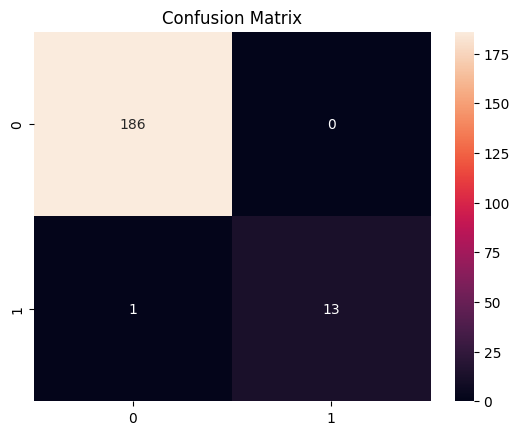

In [237]:
import seaborn as sns

cm = confusion_matrix(y_test_d, y_pred_d)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

11.MODEL SAVING

In [241]:
import os
os.listdir()


['.config',
 'dropout_detector.pkl',
 '.ipynb_checkpoints',
 'performance_predictor.pkl',
 'robust_scaler.pkl',
 'sample_data']

In [239]:
#import streamlit as st
#import pandas as pd
##import numpy as np

##st.title("🎓 AI-Driven Learning Analytics Platform")

#menu = st.sidebar.selectbox(
    #"Select Module",
   # ["Performance Prediction", "Dropout Risk"]
#)

###student_id = st.sidebar.number_input("Student ID", 1, 1000, value=1)
  #avg_quiz_score = st.sidebar.slider("Average Quiz Score", 0, 100, value=70)
#avg_assignment_score = st.sidebar.slider("Average Assignment Score", 0, 100, value=75)
# overall_completion_rate = st.sidebar.slider("Overall Completion Rate", 0.0,
# 1.0, 0.8)
#quiz_attempt_rate = st.sidebar.slider("Quiz Attempt Rate", 0.0, 1.0, 0.9)
#assignment_submission_rate = st.sidebar.slider("Assignment Submission Rate", 0.0, 1.0, 0.95)
#weakest_course_score = st.sidebar.slider("Weakest Course Score", 0, 100, value=50)
#strongest_course_score = st.sidebar.slider("Strongest Course Score", 0, 100, value=90)
#weak_topic_count = st.sidebar.number_input("Weak Topic Count", 0, 10, value=2)
#strong_topic_count = st.sidebar.number_input("Strong Topic Count", 0, 10, value=5)
#avg_topic_accuracy = st.sidebar.slider("Average Topic Accuracy", 0.0, 1.0, 0.8)
#video_completion_rate = st.sidebar.slider("Video Completion Rate", 0.0, 1.0, 0.7)
#avg_watch_time_ratio = st.sidebar.slider("Average Watch Time Ratio", 0.0, 1.0, 0.75)
#learner_level_input = st.sidebar.selectbox("Learner Level", ["Beginner", "Intermediate", "Advanced"], index=2)##


# Load models and scaler once
# Correct paths from "models/..." to "..."
#performance_model = joblib.load("performance_model.pkl")
#dropout_model = joblib.load("dropout_model.pkl")
#scaler = joblib.load("scaler.pkl")

# Define columns that need scaling (from cell xWqIKkrAxHjC)
#cols_to_scale = [
    #"avg_quiz_score", "avg_assignment_score", "overall_completion_rate",
   # "quiz_attempt_rate", "assignment_submission_rate", "weakest_course_score",
  #  "strongest_course_score", "weak_topic_count", "strong_topic_count",
 #   "avg_topic_accuracy", "video_completion_rate", "avg_watch_time_ratio"
#]

# Create a raw input DataFrame from current Streamlit inputs
#raw_input_data = pd.DataFrame([[
    #student_id, avg_quiz_score, avg_assignment_score, overall_completion_rate,
   # quiz_attempt_rate, assignment_submission_rate, weakest_course_score,
  #  strongest_course_score, weak_topic_count, strong_topic_count,
 #   avg_topic_accuracy, video_completion_rate, avg_watch_time_ratio, learner_level_input
#]], columns=[
    #"student_id", "avg_quiz_score", "avg_assignment_score", "overall_completion_rate",
   # "quiz_attempt_rate", "assignment_submission_rate", "weakest_course_score",
  #  "strongest_course_score", "weak_topic_count", "strong_topic_count",
 #   "avg_topic_accuracy", "video_completion_rate", "avg_watch_time_ratio", "learner_level"
#])

# Process raw input data for prediction:
# 1. One-hot encode learner_level
#processed_input_data = pd.get_dummies(raw_input_data, columns=['learner_level'], drop_first=True)
#if 'learner_level_Beginner' not in processed_input_data.columns:
 #   processed_input_data['learner_level_Beginner'] = 0
#if 'learner_level_Intermediate' not in processed_input_data.columns:
 #   processed_input_data['learner_level_Intermediate'] = 0

# 2. Scale numerical features
#processed_input_data[cols_to_scale] = scaler.transform(processed_input_data[cols_to_scale])

# 3. Calculate engagement_score (using scaled features)
#processed_input_data["engagement_score"] = (
 #   0.4 * processed_input_data["overall_completion_rate"] +
  #  0.3 * processed_input_data["avg_watch_time_ratio"] +
   # 0.2 * processed_input_data["avg_quiz_score"]
#)


#if menu == "Performance Prediction":
 #   st.header("📊 Predict Student Performance")
  #  if st.button("Predict Performance"):
        # Features for performance model (excluding one-hot encoded learner_level)
        # Based on the warning `Warning: Dropping non-numeric columns from X for regression: ['learner_level_Beginner', 'learner_level_Intermediate']`
   #     final_features_for_performance = [
    #        "student_id", "avg_quiz_score", "avg_assignment_score", "overall_completion_rate",
     ##      "strongest_course_score", "weak_topic_count", "strong_topic_count",
       #     "avg_topic_accuracy", "video_completion_rate", "avg_watch_time_ratio",
        #    "engagement_score"
        #]
        #prediction_input = processed_input_data[final_features_for_performance]

        #prediction = performance_model.predict(prediction_input)
        #st.success(f"Predicted Performance Score: {round(prediction[0], 2)}")

#elif menu == "Dropout Risk":
 #   st.header("📉 Predict Dropout Risk")
  #  if st.button("Predict Dropout Risk"):
        # Features for dropout risk model (including one-hot encoded learner_level)
        # Based on X_class in cell 5nwQW7zP1f99
   #     final_features_for_dropout = [
    #        "student_id", "avg_quiz_score", "avg_assignment_score", "overall_completion_rate",
     #       "quiz_attempt_rate", "assignment_submission_rate", "weakest_course_score",
      #      "strongest_course_score", "weak_topic_count", "strong_topic_count",
       #     "avg_topic_accuracy", "video_completion_rate", "avg_watch_time_ratio",
        #    "learner_level_Beginner", "learner_level_Intermediate", "engagement_score"
        #]
        #prediction_input = processed_input_data[final_features_for_dropout]

        #prediction = dropout_model.predict(prediction_input)
        #prediction_proba = dropout_model.predict_proba(prediction_input)[:, 1] # Probability of dropout (class 1)

        #if prediction[0] == 1:
         #   st.warning(f"Dropout Risk: HIGH (Probability: {prediction_proba[0]:.2f})")
        #else:
         #   st.success(f"Dropout Risk: LOW (Probability: {prediction_proba[0]:.2f})")

2026-02-18 13:33:54.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 13:33:54.675 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 13:33:54.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 13:33:54.677 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 13:33:54.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 13:33:54.680 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 13:33:54.681 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 13:33:54.683 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar